In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
import gymnasium as gym
import ale_py
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack
from stable_baselines3.common.atari_wrappers import AtariWrapper
from stable_baselines3.common.callbacks import BaseCallback
 
gym.register_envs(ale_py)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## Environment inspection 

In [2]:
env = gym.make("ALE/MsPacman-v5")
obs, info = env.reset()

print("=== SPACES ===")
print("Obs space:", env.observation_space)
print("Act space:", env.action_space)
print("Actions:", env.unwrapped.get_action_meanings())

print("\n=== INFO DICT KEYS ===")
print(info)

print("\n=== ALE PROPERTIES ===")
ale = env.unwrapped.ale
print("Lives:", ale.lives())
print("Frame number:", ale.getFrameNumber())
print("Episode frames:", ale.getEpisodeFrameNumber())
print("RAM size:", len(ale.getRAM()))
print("Legal actions:", ale.getLegalActionSet())
print("Min actions:", ale.getMinimalActionSet())

env.close()

=== SPACES ===
Obs space: Box(0, 255, (210, 160, 3), uint8)
Act space: Discrete(9)
Actions: ['NOOP', 'UP', 'RIGHT', 'LEFT', 'DOWN', 'UPRIGHT', 'UPLEFT', 'DOWNRIGHT', 'DOWNLEFT']

=== INFO DICT KEYS ===
{'lives': 3, 'episode_frame_number': 0, 'frame_number': 0}

=== ALE PROPERTIES ===
Lives: 3
Frame number: 0
Episode frames: 0
RAM size: 128
Legal actions: [<Action.NOOP: 0>, <Action.FIRE: 1>, <Action.UP: 2>, <Action.RIGHT: 3>, <Action.LEFT: 4>, <Action.DOWN: 5>, <Action.UPRIGHT: 6>, <Action.UPLEFT: 7>, <Action.DOWNRIGHT: 8>, <Action.DOWNLEFT: 9>, <Action.UPFIRE: 10>, <Action.RIGHTFIRE: 11>, <Action.LEFTFIRE: 12>, <Action.DOWNFIRE: 13>, <Action.UPRIGHTFIRE: 14>, <Action.UPLEFTFIRE: 15>, <Action.DOWNRIGHTFIRE: 16>, <Action.DOWNLEFTFIRE: 17>]
Min actions: [<Action.NOOP: 0>, <Action.UP: 2>, <Action.RIGHT: 3>, <Action.LEFT: 4>, <Action.DOWN: 5>, <Action.UPRIGHT: 6>, <Action.UPLEFT: 7>, <Action.DOWNRIGHT: 8>, <Action.DOWNLEFT: 9>]


In [3]:
import torch
print(torch.__version__)        
print(torch.cuda.is_available()) 

2.5.1+cu121
True


## Reward Shaping Wrapper

In [4]:
class RewardShapingWrapper(gym.Wrapper):
    GHOST_REWARDS = {200, 400, 800, 1600}
    FRUIT_REWARDS = {100, 300, 500, 700, 1000, 2000, 3000, 5000}
    POWER_PELLET_REWARD = 50
    REGULAR_PELLET_REWARD = 10
    POWER_PELLET_DURATION = 150  
 
    def __init__(
        self,
        env,
        ghost_chain_bonus = 12.0,
        pellet_streak_bonus = 0.03,
        fruit_multiplier = 1.05,
        death_penalty = 0.0,
    ):
        super().__init__(env)
        self.ghost_chain_bonus = ghost_chain_bonus
        self.pellet_streak_bonus = pellet_streak_bonus
        self.fruit_multiplier = fruit_multiplier
        self.death_penalty = death_penalty
 
        # Mutable state
        self._prev_lives = None
        self.ghosts_eaten = 0     
        self._pellet_streak = 0
        self._steps_since_pellet = 0
        self._power_pellet_active = False
        self._power_pellet_steps = 0
 
    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self._prev_lives = None
        self.ghosts_eaten = 0
        self._pellet_streak = 0
        self._steps_since_pellet = 0
        self._power_pellet_active = False
        self._power_pellet_steps = 0
        return obs, info
 
    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        shaped_reward = reward
        raw = int(reward)
 
        # Life tracker initialisation
        current_lives = info.get("lives", 3)
        if self._prev_lives is None:
            self._prev_lives = current_lives
 
        # Power-pellet window bookkeeping
        if self._power_pellet_active:
            self._power_pellet_steps += 1
            if self._power_pellet_steps > self.POWER_PELLET_DURATION:
                self._power_pellet_active = False
                self._power_pellet_steps = 0
                self.ghosts_eaten = 0
 
        # Ghost chain bonus
        if raw in self.GHOST_REWARDS:
            self.ghosts_eaten += 1
            if self.ghosts_eaten > 1:
                shaped_reward += self.ghost_chain_bonus * (self.ghosts_eaten - 1)
 
        # Pellet streak
        if raw == self.REGULAR_PELLET_REWARD:
            self._pellet_streak += 1
            self._steps_since_pellet = 0
            shaped_reward += self.pellet_streak_bonus * self._pellet_streak
 
        elif raw == self.POWER_PELLET_REWARD:
            self._pellet_streak += 1
            self._steps_since_pellet = 0
            shaped_reward += self.pellet_streak_bonus * self._pellet_streak
            self._power_pellet_active = True
            self._power_pellet_steps = 0
            self.ghosts_eaten = 0
 
        else:
            self._steps_since_pellet += 1
            if self._steps_since_pellet > 8:
                self._pellet_streak = 0
 
        # Fruit multiplier 
        if raw in self.FRUIT_REWARDS:
            shaped_reward += (self.fruit_multiplier - 1.0) * raw
 
        # Death penalty
        if current_lives < self._prev_lives:
            shaped_reward += self.death_penalty
        self._prev_lives = current_lives
 
        return obs, shaped_reward, terminated, truncated, info

## Experimental Conditions

In [5]:
CONDITIONS = {
    "Baseline": {
        "wrapper": None,
        "color": "blue",
        "description": "Default ALE rewards only",
    },
    "Expert Shaping": {
        "wrapper": "expert",
        "ghost_chain_bonus": 12.0,
        "pellet_streak_bonus": 0.0,
        "fruit_multiplier": 1.5,
        "death_penalty": 0.0,
        "color": "yellow",
        "description": "Chain + streak + fruit, no death penalty",
    },
    "Expert Shaping + Death Penalty": {
        "wrapper": "expert",
        "ghost_chain_bonus": 12.0,
        "pellet_streak_bonus": 0.0,
        "fruit_multiplier": 1.5,
        "death_penalty": -1.0,
        "color": "purple",
        "description": "Chain + streak + fruit + death penalty",
    },
}
 
print("Conditions defined:")
for name, cfg in CONDITIONS.items():
    print(f"  {name:35s} — {cfg['description']}")

Conditions defined:
  Baseline                            — Default ALE rewards only
  Expert Shaping                      — Chain + streak + fruit, no death penalty
  Expert Shaping + Death Penalty      — Chain + streak + fruit + death penalty


## Progress Callback (tracks metrics per episode)

In [6]:
class ExperimentCallback(BaseCallback):
    def __init__(self, condition_name, verbose= 0):
        super().__init__(verbose)
        self.condition_name = condition_name
        self.episode_rewards = []  
        self.episode_shaped_rewards = []  
        self.episode_lengths = []
        self.episode_ghosts_eaten = []
 
        self._shaped_accum = 0.0
        self._length_accum = 0
 
    def _on_step(self):
        self._shaped_accum += float(self.locals["rewards"][0])
        self._length_accum += 1
 
        if self.locals["dones"][0]:
            info = self.locals["infos"][0]
 
            # True unshaped score 
            true_r = info.get("episode", {}).get("r", self._shaped_accum)
 
            # Retrieve ghosts_eaten from the innermost wrapper that has it.
            inner_env = self.training_env.envs[0]
            while hasattr(inner_env, "env"):
                if hasattr(inner_env, "ghosts_eaten"):
                    break
                inner_env = inner_env.env
            ghosts = getattr(inner_env, "ghosts_eaten", 0)
 
            self.episode_rewards.append(float(true_r))
            self.episode_shaped_rewards.append(float(self._shaped_accum))
            self.episode_lengths.append(int(self._length_accum))
            self.episode_ghosts_eaten.append(int(ghosts))
 
            n = len(self.episode_rewards)
            if n % 50 == 0:
                w = min(20, n)
                print(
                    f"  [{self.condition_name}] Ep {n:>4} | "
                    f"Steps {self.num_timesteps:>8,} | "
                    f"True: {np.mean(self.episode_rewards[-w:]):>7.1f} | "
                    f"Shaped: {np.mean(self.episode_shaped_rewards[-w:]):>7.1f} | "
                    f"Len: {np.mean(self.episode_lengths[-w:]):>5.0f}"
                )
 
            self._shaped_accum = 0.0
            self._length_accum = 0
 
        return True

## Training Function

In [7]:
def make_env(condition_cfg, seed=42):
    def _init():
        env = gym.make("ALE/MsPacman-v5", render_mode=None)
 
        wrapper_type = condition_cfg.get("wrapper")
        if wrapper_type == "expert":
            env = RewardShapingWrapper(
                env,
                ghost_chain_bonus = condition_cfg.get("ghost_chain_bonus", 0.0),
                pellet_streak_bonus = condition_cfg.get("pellet_streak_bonus", 0.0),
                fruit_multiplier = condition_cfg.get("fruit_multiplier", 1.0),
                death_penalty = condition_cfg.get("death_penalty", 0.0),
            )
        env = AtariWrapper(env, clip_reward=False)
        env.reset(seed=seed)
        return env
 
    return _init
 
def train_condition(
    condition_name,
    condition_cfg,
    total_timesteps = 1_000_000,
    seed = 42,
):
    print(f"\n{'='*62}")
    print(f"Training: {condition_name}")
    print(f"Config: {condition_cfg['description']}")
    print(f"Steps: {total_timesteps:,}")
 
    vec_env = DummyVecEnv([make_env(condition_cfg, seed)])
    vec_env = VecFrameStack(vec_env, n_stack=4)
 
    model = PPO(
        "CnnPolicy",
        vec_env,
        n_steps = 128,
        batch_size = 256,
        n_epochs = 4,
        gamma = 0.99,
        learning_rate = 2.5e-4,
        clip_range = 0.1,
        verbose = 0,
        seed = seed,
    )
 
    callback = ExperimentCallback(condition_name)
    model.learn(total_timesteps=total_timesteps, callback=callback)
 
    steps_str = f"{total_timesteps // 1_000_000}M"
    file_name = condition_name.replace(" ", "_").replace("+", "").lower()
    file = "_".join(file_name.split())
    save_path = f"ppo_pacman_{file}_{steps_str}"
 
    model.save(save_path)
    print(f"  Model saved: {save_path}.zip")
 
    log_path = f"training_{file}_{steps_str}.json"
    with open(log_path, "w") as f:
        json.dump({
            "condition": condition_name,
            "total_steps": total_timesteps,
            "episode_rewards": callback.episode_rewards,
            "episode_shaped_rewards": callback.episode_shaped_rewards,
            "episode_lengths": callback.episode_lengths,
            "episode_ghosts_eaten": callback.episode_ghosts_eaten,
        }, f)
    print(f"  Training log → {log_path}")
 
    vec_env.close()
    return model, callback

In [8]:
TOTAL_STEPS = 7_000_000

results = {}

for name, cfg in CONDITIONS.items():
    try:
        model, callback = train_condition(name, cfg, total_timesteps=TOTAL_STEPS)
        results[name] = {
            "model": model,
            "episode_rewards": callback.episode_rewards,
            "episode_shaped_rewards": callback.episode_shaped_rewards,
            "episode_lengths": callback.episode_lengths,
            "episode_ghosts_eaten": callback.episode_ghosts_eaten,
            "total_steps": TOTAL_STEPS,
        }
        print(f"{name} complete.")
    except Exception as exc:
        print(f"{name} failed: {exc}")
        results[name] = None
 
print(f"\nAll conditions trained {TOTAL_STEPS:,} steps each.")


Training: Baseline
Config: Default ALE rewards only
Steps: 7,000,000


c:\Users\artur\AppData\Local\Programs\Python\Python310\lib\site-packages\stable_baselines3\ppo\ppo.py:155: UserWarning: You have specified a mini-batch size of 256, but because the `RolloutBuffer` is of size `n_steps * n_envs = 128`, after every 0 untruncated mini-batches, there will be a truncated mini-batch of size 128
We recommend using a `batch_size` that is a factor of `n_steps * n_envs`.
Info: (n_steps=128 and n_envs=1)
  warnings.warn(


  [Baseline] Ep   50 | Steps    2,374 | True:   159.0 | Shaped:   159.0 | Len:    53
  [Baseline] Ep  100 | Steps    4,595 | True:   112.0 | Shaped:   112.0 | Len:    45
  [Baseline] Ep  150 | Steps    7,065 | True:   119.5 | Shaped:   119.5 | Len:    46
  [Baseline] Ep  200 | Steps    9,512 | True:   178.0 | Shaped:   178.0 | Len:    52
  [Baseline] Ep  250 | Steps   12,162 | True:   150.5 | Shaped:   150.5 | Len:    58
  [Baseline] Ep  300 | Steps   14,727 | True:   121.5 | Shaped:   121.5 | Len:    47
  [Baseline] Ep  350 | Steps   17,363 | True:   199.0 | Shaped:   199.0 | Len:    55
  [Baseline] Ep  400 | Steps   19,944 | True:   181.0 | Shaped:   181.0 | Len:    46
  [Baseline] Ep  450 | Steps   22,367 | True:   160.5 | Shaped:   160.5 | Len:    48
  [Baseline] Ep  500 | Steps   25,006 | True:   251.5 | Shaped:   251.5 | Len:    55
  [Baseline] Ep  550 | Steps   27,634 | True:   269.0 | Shaped:   269.0 | Len:    48
  [Baseline] Ep  600 | Steps   30,197 | True:   192.0 | Shaped:  

c:\Users\artur\AppData\Local\Programs\Python\Python310\lib\site-packages\stable_baselines3\ppo\ppo.py:155: UserWarning: You have specified a mini-batch size of 256, but because the `RolloutBuffer` is of size `n_steps * n_envs = 128`, after every 0 untruncated mini-batches, there will be a truncated mini-batch of size 128
We recommend using a `batch_size` that is a factor of `n_steps * n_envs`.
Info: (n_steps=128 and n_envs=1)
  warnings.warn(


  [Expert Shaping] Ep   50 | Steps    2,374 | True:   159.0 | Shaped:   159.0 | Len:    53
  [Expert Shaping] Ep  100 | Steps    4,595 | True:   112.0 | Shaped:   112.0 | Len:    45
  [Expert Shaping] Ep  150 | Steps    7,065 | True:   119.5 | Shaped:   119.5 | Len:    46
  [Expert Shaping] Ep  200 | Steps    9,512 | True:   178.0 | Shaped:   178.0 | Len:    52
  [Expert Shaping] Ep  250 | Steps   12,162 | True:   150.5 | Shaped:   150.5 | Len:    58
  [Expert Shaping] Ep  300 | Steps   14,727 | True:   121.5 | Shaped:   121.5 | Len:    47
  [Expert Shaping] Ep  350 | Steps   17,299 | True:   176.1 | Shaped:   176.1 | Len:    48
  [Expert Shaping] Ep  400 | Steps   19,511 | True:   146.5 | Shaped:   146.5 | Len:    48
  [Expert Shaping] Ep  450 | Steps   22,191 | True:   160.0 | Shaped:   160.0 | Len:    52
  [Expert Shaping] Ep  500 | Steps   24,750 | True:   254.9 | Shaped:   254.9 | Len:    55
  [Expert Shaping] Ep  550 | Steps   27,405 | True:   138.0 | Shaped:   138.0 | Len:    54

## Evaluation Function

In [9]:
def evaluate_agent(model, n_episodes=100, seed=99):
    def _make_eval_env():
        env = gym.make("ALE/MsPacman-v5")
        env = AtariWrapper(env, clip_reward=False)
        env.reset(seed=seed)
        return env
 
    eval_env = DummyVecEnv([_make_eval_env])
    eval_env = VecFrameStack(eval_env, n_stack=4)
 
    GHOST_REWARD_VALUES = {200, 400, 800, 1600}
 
    scores, lengths, ghost_chains, ghosts_eaten, score_per_step = [], [], [], [], []
 
    for _ in range(n_episodes):
        obs = eval_env.reset()
        total_score = 0.0
        length = 0
        done  = False
        current_chain = 0
        max_chain = 0
        ep_ghosts = 0
        prev_lives = 3
 
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done_arr, info = eval_env.step(action)
            done = bool(done_arr[0])
            r = float(reward[0])
            total_score += r
            length      += 1
 
            # Ghost chain tracking 
            raw_r = int(round(r))
            if raw_r in GHOST_REWARD_VALUES:
                current_chain += 1
                max_chain = max(max_chain, current_chain)
                ep_ghosts += 1
            # power pellet resets chain
            elif raw_r == 50:         
                current_chain = 0
 
            # Death resets chain
            current_lives = info[0].get("lives", prev_lives)
            if current_lives < prev_lives:
                current_chain = 0
            prev_lives = current_lives
 
        scores.append(total_score)
        lengths.append(length)
        ghost_chains.append(max_chain)
        ghosts_eaten.append(ep_ghosts)
        score_per_step.append(total_score / length if length > 0 else 0.0)
 
    eval_env.close()
 
    return {
        "scores": np.array(scores),
        "lengths": np.array(lengths),
        "ghost_chains": np.array(ghost_chains),
        "ghosts_eaten": np.array(ghosts_eaten),
        "score_per_step": np.array(score_per_step),
    }

## Evaluate All Conditions

In [10]:
eval_results = {}
steps_str = f"{TOTAL_STEPS // 1_000_000}M"
 
for name, data in results.items():
    if data is None:
        print(f"  Skipping {name} — training failed.")
        continue
 
    print(f"Evaluating {name} …")
    er   = evaluate_agent(data["model"], n_episodes=100, seed=99)
    file_name = name.replace(" ", "_").replace("+", "").lower()
    file_name = "_".join(file_name.split())
 
    eval_results[name] = er
 
    save_name = f"eval_{file_name}_{steps_str}.json"
    with open(save_name, "w") as f:
        json.dump({k: v.tolist() for k, v in er.items()} | {"condition": name, "steps": TOTAL_STEPS}, f)
    print(f"  Saved → {save_name}")
 
display(pd.DataFrame({
    name: {
        "Avg Score": round(float(np.mean(er["scores"])), 1),
        "Std": round(float(np.std(er["scores"])), 1),
        "Survival": round(float(np.mean(er["lengths"])), 1),
        "Ghost Chain": round(float(np.mean(er["ghost_chains"])), 2),
        "Ghosts/ep": round(float(np.mean(er["ghosts_eaten"])), 1),
        "Score/step": round(float(np.mean(er["score_per_step"])), 3),
    }
    for name, er in eval_results.items()
}).T)

Evaluating Baseline …
  Saved → eval_baseline_7M.json
Evaluating Expert Shaping …
  Saved → eval_expert_shaping_7M.json
Evaluating Expert Shaping + Death Penalty …
  Saved → eval_expert_shaping__death_penalty_7M.json


,Avg Score,Std,Survival,Ghost Chain,Ghosts/ep,Score/step
Baseline,509.5,521.9,61.7,0.43,0.5,6.651
Expert Shaping,246.0,258.7,60.7,0.28,0.3,3.712
Expert Shaping + Death Penalty,664.4,644.8,67.7,0.54,0.6,7.876


## Learning Efficiency Analysis 

Learning Efficiency — 7,000,000 steps


,Threshold,Episodes,Steps,Train Avg,Eval Score
Baseline,384.5,16480,"829,474",528.7,509.5
Expert Shaping,293.9,2476,"119,747",250.4,246.0
Expert Shaping + Death Penalty,387.9,30427,"1,548,768",715.1,664.4


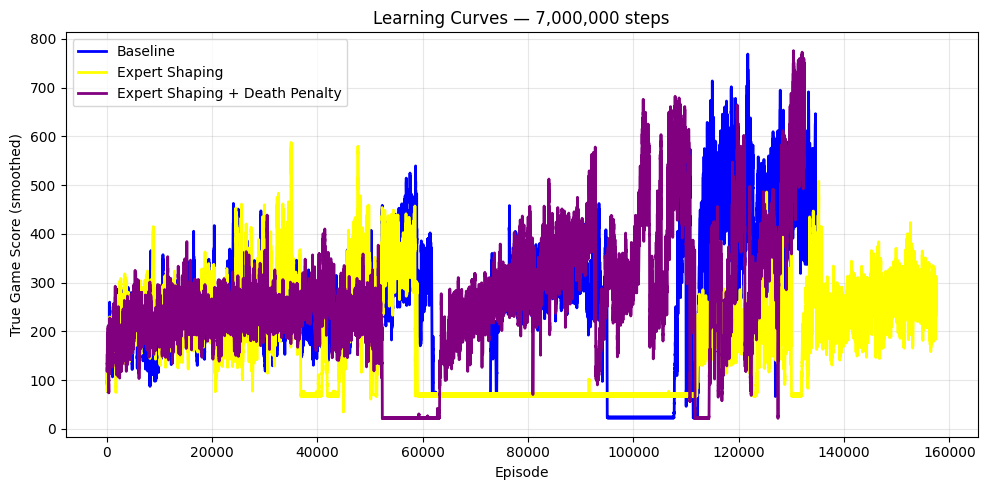

In [11]:
def smooth(arr, window = 50):
    arr = np.asarray(arr, dtype = float)
    if len(arr) < window:
        return arr
    return np.convolve(arr, np.ones(window) / window, mode="valid")

def steps_to_threshold(
    episode_rewards,
    episode_lengths,
    threshold,
    window = 50,
):
    rewards = np.asarray(episode_rewards, dtype=float)
    lengths = np.asarray(episode_lengths, dtype=float)
    smoothed = smooth(rewards, window)
    above = np.where(smoothed >= threshold)[0]
    if len(above) == 0:
        return None, None
    ep_idx = int(above[0]) + (window - 1)
    step_count = int(np.sum(lengths[: ep_idx + 1]))
    return ep_idx, step_count
 
print(f"Learning Efficiency — {TOTAL_STEPS:,} steps")
efficiency = {}
 
for name, data in results.items():
    if data is None:
        continue
    rewards = np.asarray(data["episode_rewards"], dtype=float)
    smoothed = smooth(rewards, window=50)
    own_best = float(np.max(smoothed)) if len(smoothed) else 0.0
    threshold = 0.5 * own_best
    final_avg = float(np.mean(rewards[-100:])) if len(rewards) >= 100 else float(np.mean(rewards))
    ep, steps = steps_to_threshold(rewards, data["episode_lengths"], threshold)
    efficiency[name] = {
        "threshold": round(threshold, 1),
        "episodes_to_threshold": ep,
        "steps_to_threshold": steps,
        "final_train_avg": round(final_avg, 1),
        "eval_score": round(float(np.mean(eval_results[name]["scores"])), 1) if name in eval_results else None,
    }
 
display(pd.DataFrame({
    name: {
        "Threshold": e["threshold"],
        "Episodes": e["episodes_to_threshold"] or "Never",
        "Steps": f"{e['steps_to_threshold']:,}" if e["steps_to_threshold"] else "Never",
        "Train Avg": e["final_train_avg"],
        "Eval Score": e["eval_score"],
    }
    for name, e in efficiency.items()
}).T)

def plot_learning_curves(results, CONDITIONS, TOTAL_STEPS):
    fig, ax = plt.subplots(figsize=(10, 5))
    
    for name, data in results.items():
        if data is None:
            continue
        rewards = pd.Series(data["episode_rewards"])
        ax.plot(rewards.rolling(50).mean(), 
                color=CONDITIONS[name]["color"], 
                linewidth=2, label=name)
    
    ax.set_xlabel("Episode")
    ax.set_ylabel("True Game Score (smoothed)")
    ax.set_title(f"Learning Curves — {TOTAL_STEPS:,} steps")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(f"plot_learning_curves_{TOTAL_STEPS // 1_000_000}M.png", dpi=130)
    plt.show()

plot_learning_curves(results, CONDITIONS, TOTAL_STEPS)

## Score Distribution Box Plot

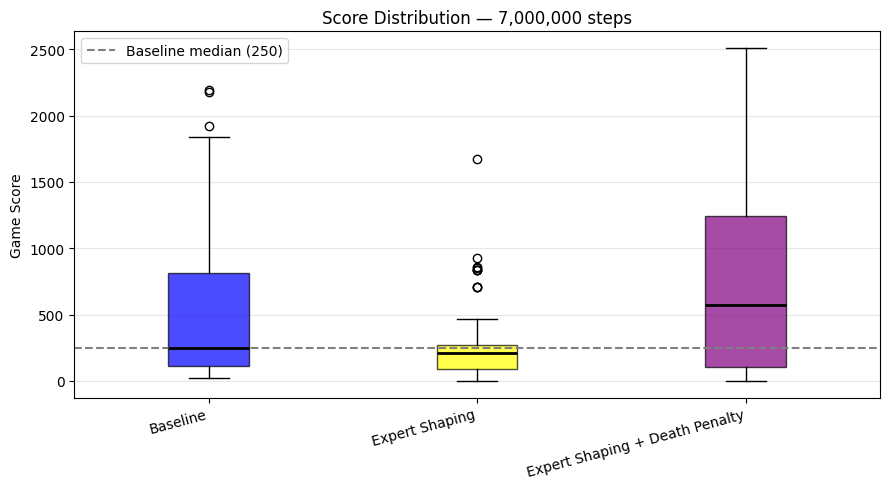

In [12]:
def plot_score_distribution(eval_results, CONDITIONS, TOTAL_STEPS):
    fig, ax = plt.subplots(figsize=(9, 5))
    
    names = list(eval_results.keys())
    colors = [CONDITIONS[n]["color"] for n in names]
    
    bp = ax.boxplot([eval_results[n]["scores"] for n in names],
                    patch_artist=True,
                    medianprops=dict(color="black", linewidth=2))
    
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    if "Baseline" in eval_results:
        bm = np.median(eval_results["Baseline"]["scores"])
        ax.axhline(bm, color="gray", linestyle="--", linewidth=1.5,
                   label=f"Baseline median ({bm:.0f})")

    ax.set_xticks(range(1, len(names) + 1))
    ax.set_xticklabels(names, rotation=15, ha="right")
    ax.set_ylabel("Game Score")
    ax.set_title(f"Score Distribution — {TOTAL_STEPS:,} steps")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    fig.savefig(f"plot_score_distribution_{TOTAL_STEPS // 1_000_000}M.png", dpi=130)
    plt.show()

plot_score_distribution(eval_results, CONDITIONS, TOTAL_STEPS)

## Statistical Summary 

In [13]:
print(f"\nFULL STATISTICAL SUMMARY-{TOTAL_STEPS // 1_000_000}M steps")

display(pd.DataFrame({
    name: {
        "Mean Score": round(np.mean(er["scores"]), 1),
        "Std": round(np.std(er["scores"]), 1),
        "Max Score": int(np.max(er["scores"])),
        "Survival": round(np.mean(er["lengths"]), 1),
        "Ghost Chain": round(np.mean(er["ghost_chains"]), 2),
        "Ghosts/ep": round(np.mean(er.get("ghosts_eaten_total", [0])), 1),
        "Score/step": round(np.mean(er["score_per_step"]), 3),
    }
    for name, er in eval_results.items()
}).T)

# Baseline comparison table 
if "Baseline" in eval_results:
    b_score = np.mean(eval_results["Baseline"]["scores"])
    b_length = np.mean(eval_results["Baseline"]["lengths"])

    print(f"\nComparison vs Baseline")
    display(pd.DataFrame({
        name: {
            "Score Diff": round(np.mean(er["scores"]) - b_score,  1),
            "Beats BL?": "YES" if np.mean(er["scores"]) > b_score  else "NO",
            "Survival Diff":round(np.mean(er["lengths"]) - b_length, 1),
            "Survival Dir": "↑" if np.mean(er["lengths"]) - b_length > 1
                            else "↓" if np.mean(er["lengths"]) - b_length < -1
                            else "=",
        }
        for name, er in eval_results.items()
    }).T)


FULL STATISTICAL SUMMARY-7M steps


,Mean Score,Std,Max Score,Survival,Ghost Chain,Ghosts/ep,Score/step
Baseline,509.5,521.9,2190.0,61.7,0.43,0.0,6.651
Expert Shaping,246.0,258.7,1670.0,60.7,0.28,0.0,3.712
Expert Shaping + Death Penalty,664.4,644.8,2510.0,67.7,0.54,0.0,7.876



Comparison vs Baseline


,Score Diff,Beats BL?,Survival Diff,Survival Dir
Baseline,0.0,NO,0.0,=
Expert Shaping,-263.5,NO,-1.0,=
Expert Shaping + Death Penalty,154.9,YES,6.0,↑


## Reward Hacking Detection 

In [14]:
if results.get("Baseline") is None or eval_results.get("Baseline") is None:
    raise ValueError("Baseline results missing, run Baseline training first.")
 
baseline_train = float(np.mean(results["Baseline"]["episode_rewards"][-100:]))
baseline_eval = float(np.mean(eval_results["Baseline"]["scores"]))
 
hacking = {}
for name, data in results.items():
    if data is None or name not in eval_results:
        continue
    train_r = float(np.mean(data["episode_rewards"][-100:]))
    eval_s  = float(np.mean(eval_results[name]["scores"]))
    ratio   = round(eval_s / train_r, 2) if train_r > 0 else 1.0
 
    if name == "Baseline":
        verdict = "Reference"
    elif train_r > baseline_train and eval_s < baseline_eval and ratio < 0.6:
        verdict = "HACKING"
    elif train_r > baseline_train and eval_s < baseline_eval:
        verdict = "LIKELY"
    elif eval_s < baseline_eval:
        verdict = "Underperforms"
    else:
        verdict = "Clean"
 
    hacking[name] = {
        "Train Reward": round(train_r, 1),
        "Eval Score": round(eval_s, 1),
        "Ratio": ratio,
        "vs BL": round(eval_s - baseline_eval, 1),
        "Verdict": verdict,
    }
 
print(f"\nREWARD HACKING ANALYSIS — {TOTAL_STEPS:,} steps")
print("Ratio = eval / train  (1.0 = aligned, <0.6 = likely hacking)")
display(pd.DataFrame(hacking).T)


REWARD HACKING ANALYSIS — 7,000,000 steps
Ratio = eval / train  (1.0 = aligned, <0.6 = likely hacking)


,Train Reward,Eval Score,Ratio,vs BL,Verdict
Baseline,528.7,509.5,0.96,0.0,Reference
Expert Shaping,250.4,246.0,0.98,-263.5,Underperforms
Expert Shaping + Death Penalty,715.1,664.4,0.93,154.9,Clean


## Research Question Answer Matrix

In [15]:
b_score  = float(np.mean(eval_results["Baseline"]["scores"]))
b_length = float(np.mean(eval_results["Baseline"]["lengths"]))
b_chain  = float(np.mean(eval_results["Baseline"]["ghost_chains"]))
b_sp = float(np.mean(eval_results["Baseline"]["score_per_step"]))
b_ghosts = float(np.mean(eval_results["Baseline"]["ghosts_eaten"]))
b_train  = float(np.mean(results["Baseline"]["episode_rewards"][-100:]))
 
def _arrow(delta, threshold=0.5):
    if delta >  threshold: return "↑"
    if delta < -threshold: return "↓"
    return "="
 
print(f"\nRQ1: Does strategy-informed shaping outperform baseline? — {TOTAL_STEPS:,} steps")
display(pd.DataFrame({
    name: {
        "Eval Score": round(float(np.mean(er["scores"])), 1),
        "vs Baseline": round(float(np.mean(er["scores"])) - b_score, 1),
        "Verdict": (
            "Reference" if name == "Baseline" else
            "BEATS" if float(np.mean(er["scores"])) > b_score else
            "Similar" if float(np.mean(er["scores"])) > b_score - 20 else
            "BELOW"
        ),
    }
    for name, er in eval_results.items()
}).T)
 
print("\nRQ2: Did shaping alter behaviour beyond score?")
display(pd.DataFrame({
    name: {
        "Survival": f"{_arrow(d := float(np.mean(er['lengths'])) - b_length)}{d:+.1f}",
        "Chain": f"{_arrow(d := float(np.mean(er['ghost_chains'])) - b_chain, 0.05)}{d:+.2f}",
        "Ghosts/ep": f"{_arrow(d := float(np.mean(er['ghosts_eaten'])) - b_ghosts, 0.05)}{d:+.2f}",
        "Score/step": f"{_arrow(d := float(np.mean(er['score_per_step'])) - b_sp, 0.001)}{d:+.3f}",
    }
    for name, er in eval_results.items()
}).T)
 
print("\nRQ3: Evidence of reward hacking?")
display(pd.DataFrame({
    name: {
        "Train": round(t := float(np.mean(data["episode_rewards"][-100:])), 1),
        "Eval": round(e := float(np.mean(eval_results[name]["scores"])), 1),
        "Ratio": round(e / t if t > 0 else 1.0, 2),
        "vs BL": round(t - b_train, 1),
        "Verdict": (
            "Reference" if name == "Baseline" else
            "HACKING" if t > b_train and e < b_score and e / t < 0.6 else
            "LIKELY" if t > b_train and e < b_score else
            "Underperforms" if e < b_score else
            "Clean"
        ),
    }
    for name, data in results.items()
    if data is not None and name in eval_results
}).T)
print("Ratio = eval/train  (1.0 = clean, <0.6 = hacking)")


RQ1: Does strategy-informed shaping outperform baseline? — 7,000,000 steps


,Eval Score,vs Baseline,Verdict
Baseline,509.5,0.0,Reference
Expert Shaping,246.0,-263.5,BELOW
Expert Shaping + Death Penalty,664.4,154.9,BEATS



RQ2: Did shaping alter behaviour beyond score?


,Survival,Chain,Ghosts/ep,Score/step
Baseline,=+0.0,=+0.00,=+0.00,=+0.000
Expert Shaping,↓-1.0,↓-0.15,↓-0.18,↓-2.940
Expert Shaping + Death Penalty,↑+6.0,↑+0.11,↑+0.13,↑+1.225



RQ3: Evidence of reward hacking?


,Train,Eval,Ratio,vs BL,Verdict
Baseline,528.7,509.5,0.96,0.0,Reference
Expert Shaping,250.4,246.0,0.98,-278.3,Underperforms
Expert Shaping + Death Penalty,715.1,664.4,0.93,186.4,Clean


Ratio = eval/train  (1.0 = clean, <0.6 = hacking)


## Evaluation of the saved models

In [16]:
TOTAL_STEPS = 1_000_000
steps_str   = f"{TOTAL_STEPS // 1_000_000}M"
 
NAME_TO_SLUG = {
    "Baseline": "baseline",
    "Expert Shaping": "expert_shaping",
    "Expert Shaping + Death Penalty": "expert_shaping__death_penalty",
}
 
eval_results = {}
results = {}
 
for name, slug in NAME_TO_SLUG.items():
    model_path = f"ppo_pacman_{slug}_{steps_str}"
    training_path = f"training_{slug}_{steps_str}.json"
    eval_path = f"eval_{slug}_{steps_str}.json"
 
    # load model
    try:
        model = PPO.load(model_path)
        print(f"Loaded {model_path}.zip")
    except FileNotFoundError:
        print(f"  {model_path}.zip not found — skipping {name}")
        results[name] = None
        continue
 
    # ── evaluate (or use cached result) 
    if os.path.exists(eval_path):
        with open(eval_path) as f:
            raw = json.load(f)
        er = {k: np.array(v) for k, v in raw.items() if k not in ("condition", "steps")}
        print(f"  Eval loaded from cache: {eval_path}")
    else:
        er = evaluate_agent(model, n_episodes=100, seed=99)
        with open(eval_path, "w") as f:
            json.dump({k: v.tolist() for k, v in er.items()} | {"condition": name, "steps": TOTAL_STEPS}, f)
        print(f"  Eval complete + saved: {eval_path}")
    eval_results[name] = er
 
    # ── load training log 
    if os.path.exists(training_path):
        with open(training_path) as f:
            td = json.load(f)
        results[name] = {
            "episode_rewards": td["episode_rewards"],
            "episode_shaped_rewards": td.get("episode_shaped_rewards", td["episode_rewards"]),
            "episode_lengths": td["episode_lengths"],
            "episode_ghosts_eaten": td.get("episode_ghosts_eaten", []),
            "total_steps": TOTAL_STEPS,
            "model": model,
        }
        print(f"  Training log loaded:  {training_path}")
    else:
        print(f"  No training log found — plots will be empty for {name}")
        results[name] = {
            "episode_rewards": [], "episode_shaped_rewards": [],
            "episode_lengths": [], "episode_ghosts_eaten": [],
            "total_steps": TOTAL_STEPS, "model": model,
        }
    print()
 
# Summary
display(pd.DataFrame({
    name: {
        "Avg Score": round(float(np.mean(er["scores"])), 1),
        "Std": round(float(np.std(er["scores"])), 1),
        "Survival": round(float(np.mean(er["lengths"])), 1),
        "Ghost Chain": round(float(np.mean(er["ghost_chains"])), 2),
        "Ghosts/ep": round(float(np.mean(er["ghosts_eaten"])), 1),
        "Score/step": round(float(np.mean(er["score_per_step"])), 3),
    }
    for name, er in eval_results.items()
}).T)
print(f"\n{len(eval_results)} conditions loaded {TOTAL_STEPS:,} steps")

  ppo_pacman_baseline_1M.zip not found — skipping Baseline
  ppo_pacman_expert_shaping_1M.zip not found — skipping Expert Shaping
  ppo_pacman_expert_shaping__death_penalty_1M.zip not found — skipping Expert Shaping + Death Penalty


""



0 conditions loaded 1,000,000 steps
